In [1]:
from google.colab import files
uploaded = files.upload()

Saving pudb_eda.csv to pudb_eda.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('pudb_eda.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (46526, 43)


,Year,LoanCharacteristicsID,Bank,FIPSStateNumericCode,FIPSCountyCode,CoreBasedStatisticalAreaCode,CensusTractMinorityRatioPercent,CensusTractMedFamIncomeAmount,LocalAreaMedianIncomeAmount,HUDMedianIncomeAmount,...,Borrower2SexType,Borrower1Race1Type,Borrower2Race1Type,EmploymentBorrowerSelfEmployed,min_credit_score,avg_age,income_annual,income_group,credit_group,age_group
0,2024,2820897,Boston,33,17,14460,11.059,124693,123334,141300,...,NaN,5.0,8.0,1,4,45.0,175260,High,700-759,45-59
1,2024,2820898,Boston,23,31,38860,6.084,96420,95979,108500,...,NaN,5.0,8.0,0,5,29.0,100776,High,760+,<30
2,2024,2820899,Boston,23,7,99999,4.842,73583,70228,80600,...,NaN,NaN,8.0,0,4,47.0,169188,High,700-759,45-59
3,2024,2820900,Boston,33,11,31700,15.965,109145,109292,121800,...,1.0,5.0,5.0,0,4,30.0,167196,High,700-759,30-44
4,2024,2820901,Boston,25,17,14460,16.481,146284,134646,142000,...,1.0,NaN,NaN,0,4,28.0,132612,High,700-759,<30


In [3]:
# Quick check on key columns
cols = ['NoteRatePercent', 'LTVRatioPercent', 'TotalDebtExpenseRatioPercent',
        'min_credit_score', 'TotalMonthlyIncomeAmount', 'avg_age',
        'income_group', 'credit_group', 'age_group']

print("=== Key Column Stats ===")
print(df[cols].describe().round(2))

print("\n=== Group Distributions ===")
print("Income Group:\n", df['income_group'].value_counts())
print("\nCredit Group:\n", df['credit_group'].value_counts())
print("\nAge Group:\n", df['age_group'].value_counts())

=== Key Column Stats ===
       NoteRatePercent  LTVRatioPercent  TotalDebtExpenseRatioPercent  \
count         46526.00         46526.00                      46526.00   
mean              6.53            75.17                         33.96   
std               0.59            17.62                          9.27   
min               3.12             1.00                          3.08   
25%               6.25            69.00                         27.29   
50%               6.62            80.00                         34.76   
75%               6.88            88.00                         41.08   
max               8.38           100.00                         85.13   

       min_credit_score  TotalMonthlyIncomeAmount   avg_age  
count          46526.00                  46526.00  46526.00  
mean               4.36                  13101.72     42.88  
std                0.80                   9746.48     13.87  
min                1.00                    943.00     18.00  
25%    

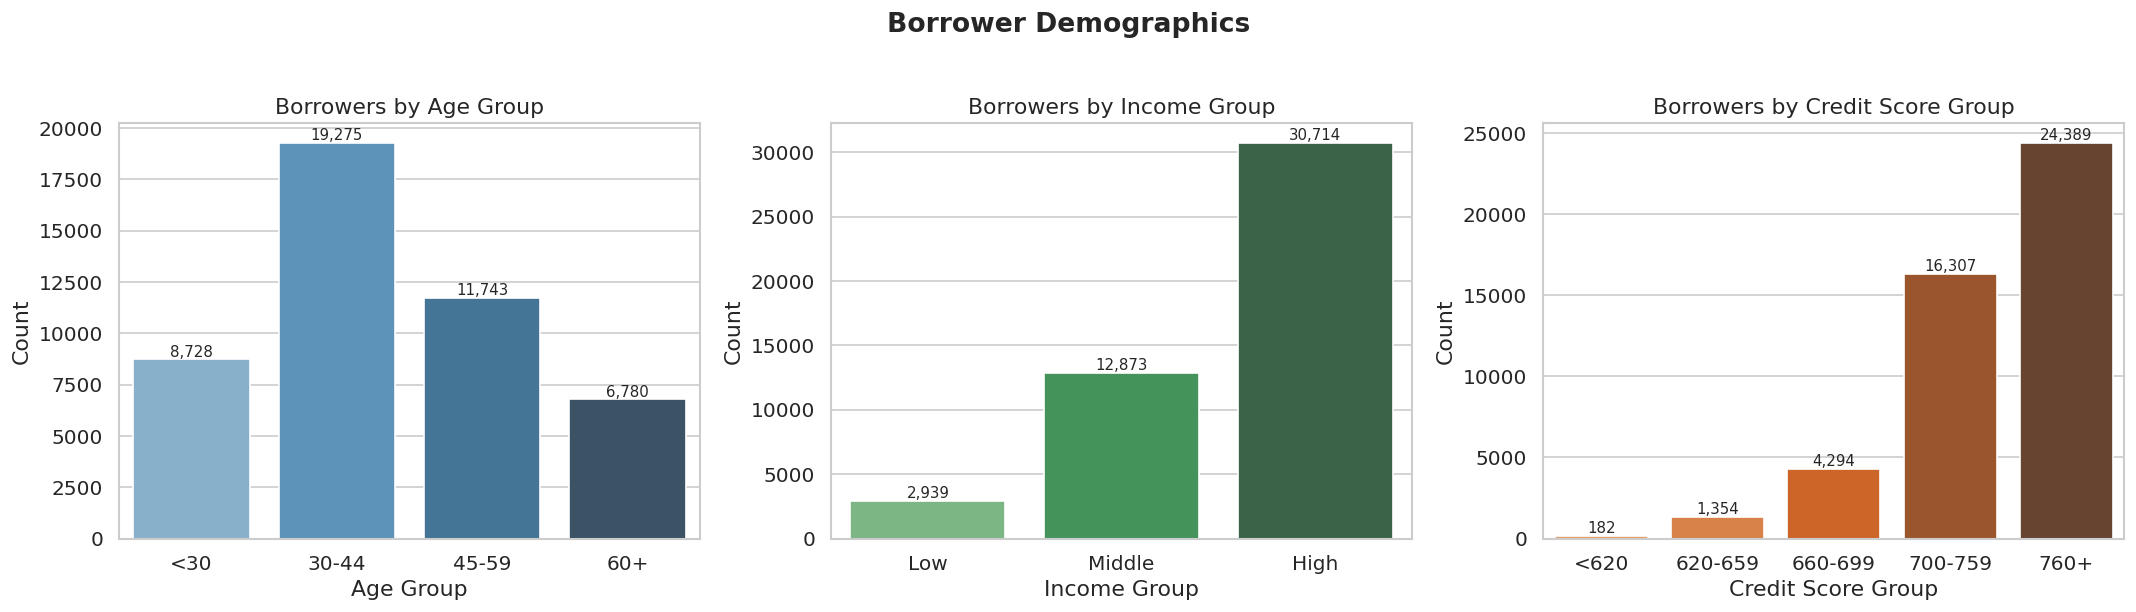

In [4]:
# ── Plot 1: Borrower Demographics ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Borrower Demographics', fontsize=16, fontweight='bold', y=1.02)

# Age Group
age_order = ['<30', '30-44', '45-59', '60+']
sns.countplot(data=df, x='age_group', order=age_order, palette='Blues_d', ax=axes[0])
axes[0].set_title('Borrowers by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Income Group
income_order = ['Low', 'Middle', 'High']
sns.countplot(data=df, x='income_group', order=income_order, palette='Greens_d', ax=axes[1])
axes[1].set_title('Borrowers by Income Group')
axes[1].set_xlabel('Income Group')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Credit Group
credit_order = ['<620', '620-659', '660-699', '700-759', '760+']
sns.countplot(data=df, x='credit_group', order=credit_order, palette='Oranges_d', ax=axes[2])
axes[2].set_title('Borrowers by Credit Score Group')
axes[2].set_xlabel('Credit Score Group')
axes[2].set_ylabel('Count')
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot1_demographics.png', bbox_inches='tight')
plt.show()

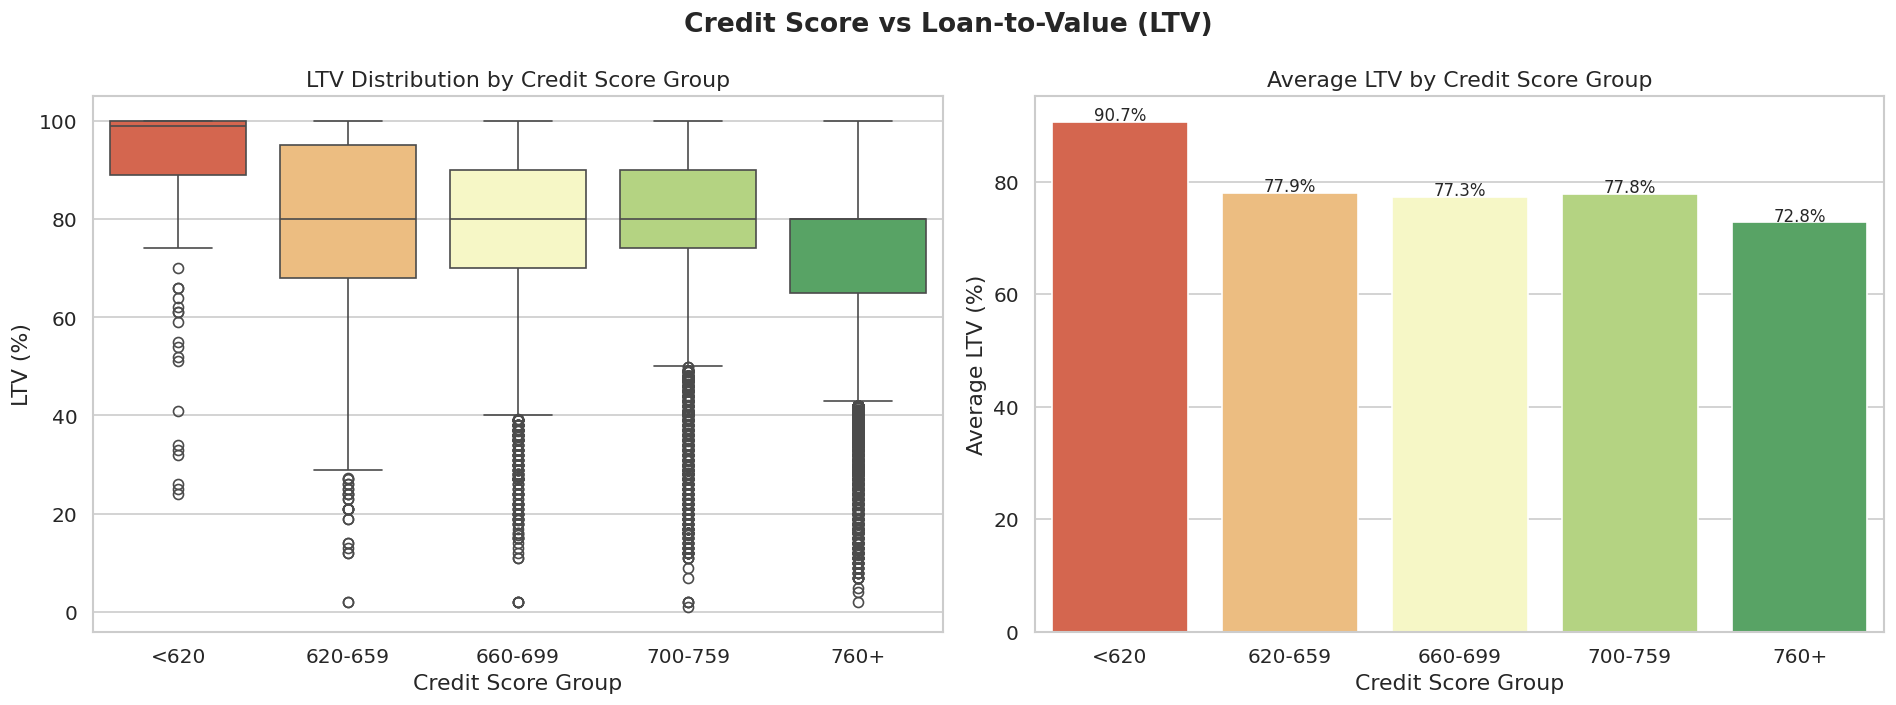

In [5]:
# ── Plot 2: Credit Score vs LTV ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Credit Score vs Loan-to-Value (LTV)', fontsize=16, fontweight='bold')

credit_order = ['<620', '620-659', '660-699', '700-759', '760+']

# Boxplot
sns.boxplot(data=df, x='credit_group', order=credit_order,
            y='LTVRatioPercent', palette='RdYlGn', ax=axes[0])
axes[0].set_title('LTV Distribution by Credit Score Group')
axes[0].set_xlabel('Credit Score Group')
axes[0].set_ylabel('LTV (%)')

# Mean LTV bar chart
mean_ltv = df.groupby('credit_group')['LTVRatioPercent'].mean().reindex(credit_order)
sns.barplot(x=mean_ltv.index, y=mean_ltv.values, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Average LTV by Credit Score Group')
axes[1].set_xlabel('Credit Score Group')
axes[1].set_ylabel('Average LTV (%)')
for i, v in enumerate(mean_ltv.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot2_credit_vs_ltv.png', bbox_inches='tight')
plt.show()

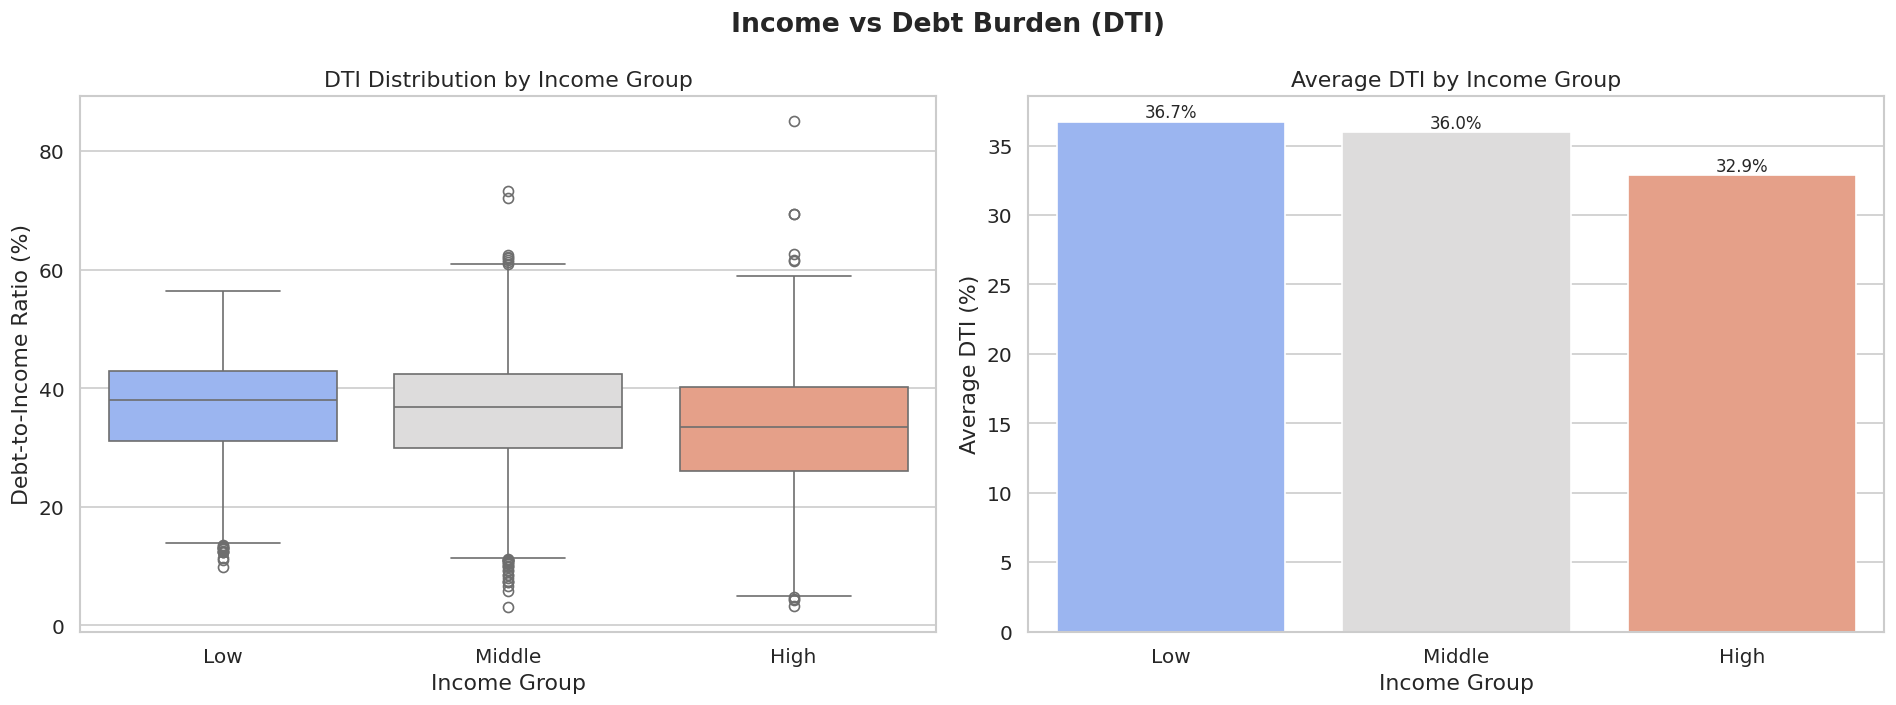

In [6]:
# ── Plot 3: Income vs Debt Burden (DTI) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Income vs Debt Burden (DTI)', fontsize=16, fontweight='bold')

income_order = ['Low', 'Middle', 'High']

# Boxplot
sns.boxplot(data=df, x='income_group', order=income_order,
            y='TotalDebtExpenseRatioPercent', palette='coolwarm', ax=axes[0])
axes[0].set_title('DTI Distribution by Income Group')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Debt-to-Income Ratio (%)')

# Mean DTI bar chart
mean_dti = df.groupby('income_group')['TotalDebtExpenseRatioPercent'].mean().reindex(income_order)
sns.barplot(x=mean_dti.index, y=mean_dti.values, palette='coolwarm', ax=axes[1])
axes[1].set_title('Average DTI by Income Group')
axes[1].set_xlabel('Income Group')
axes[1].set_ylabel('Average DTI (%)')
for i, v in enumerate(mean_dti.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot3_income_vs_dti.png', bbox_inches='tight')
plt.show()

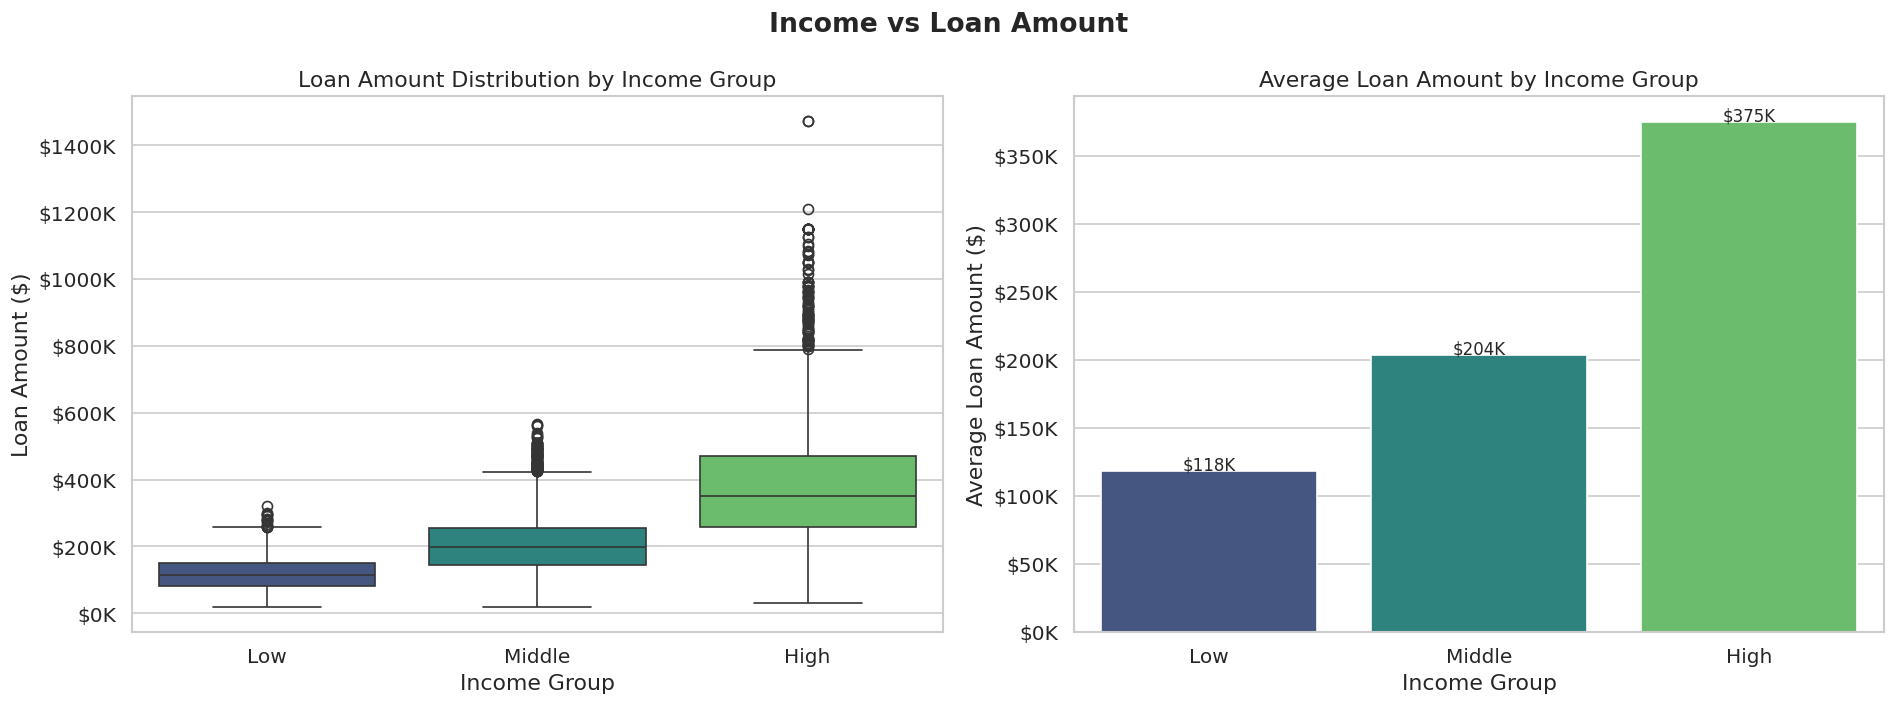

In [7]:
# ── Plot 4: Income vs Loan Amount ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Income vs Loan Amount', fontsize=16, fontweight='bold')

income_order = ['Low', 'Middle', 'High']

# Boxplot
sns.boxplot(data=df, x='income_group', order=income_order,
            y='NoteAmount', palette='viridis', ax=axes[0])
axes[0].set_title('Loan Amount Distribution by Income Group')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Loan Amount ($)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Mean loan amount bar chart
mean_loan = df.groupby('income_group')['NoteAmount'].mean().reindex(income_order)
sns.barplot(x=mean_loan.index, y=mean_loan.values, palette='viridis', ax=axes[1])
axes[1].set_title('Average Loan Amount by Income Group')
axes[1].set_xlabel('Income Group')
axes[1].set_ylabel('Average Loan Amount ($)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, v in enumerate(mean_loan.values):
    axes[1].text(i, v + 1000, f'${v/1000:.0f}K', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot4_income_vs_loanamount.png', bbox_inches='tight')
plt.show()

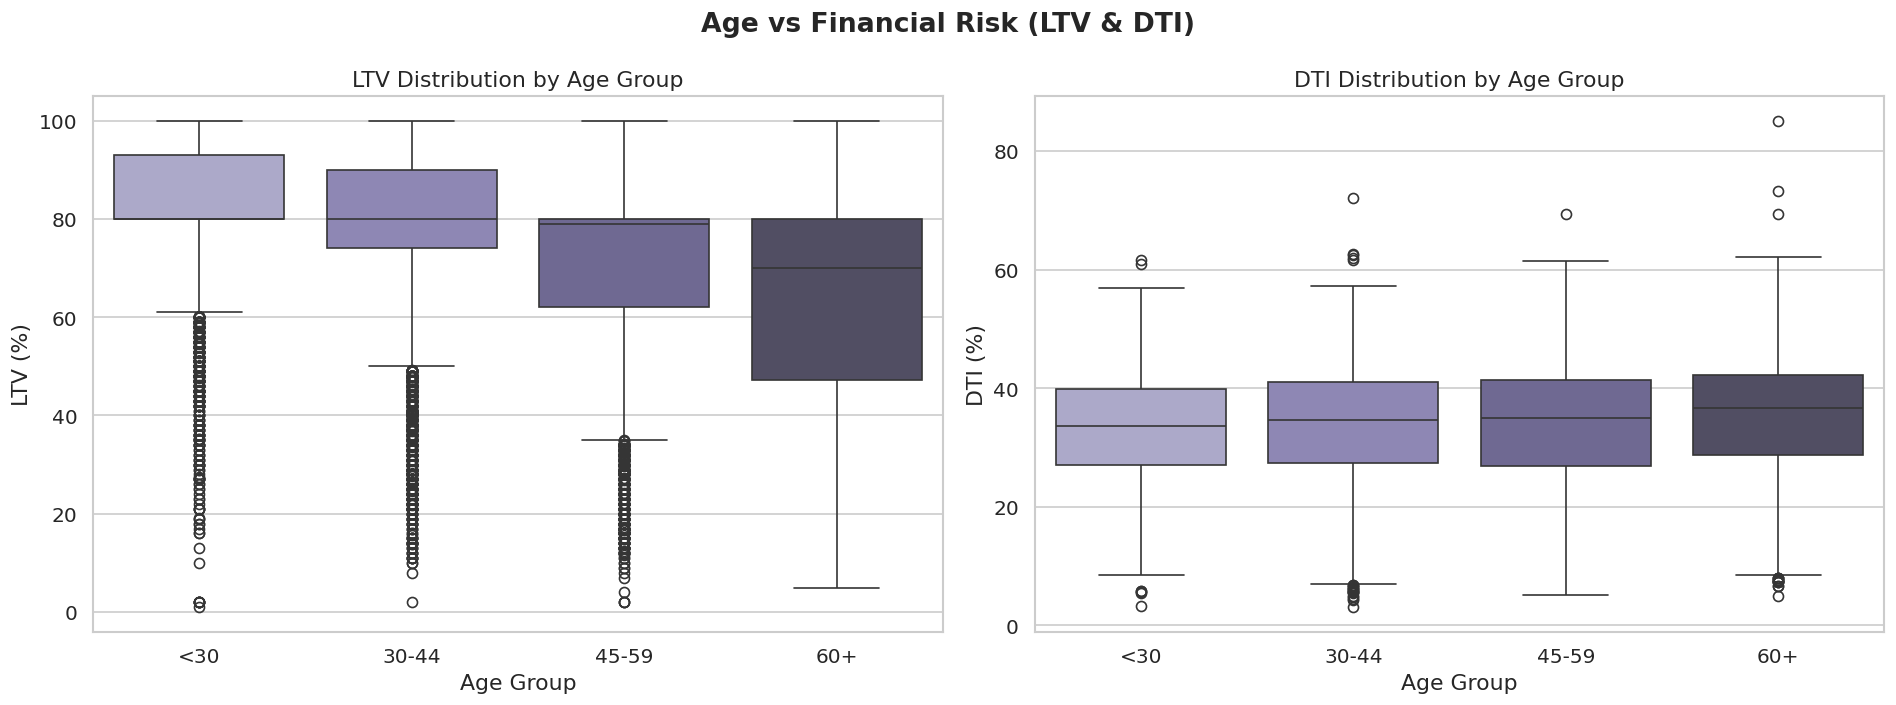

In [8]:
# ── Plot 5: Age vs Financial Risk ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Age vs Financial Risk (LTV & DTI)', fontsize=16, fontweight='bold')

age_order = ['<30', '30-44', '45-59', '60+']

# Age vs LTV
sns.boxplot(data=df, x='age_group', order=age_order,
            y='LTVRatioPercent', palette='Purples_d', ax=axes[0])
axes[0].set_title('LTV Distribution by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('LTV (%)')

# Age vs DTI
sns.boxplot(data=df, x='age_group', order=age_order,
            y='TotalDebtExpenseRatioPercent', palette='Purples_d', ax=axes[1])
axes[1].set_title('DTI Distribution by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('DTI (%)')

plt.tight_layout()
plt.savefig('plot5_age_vs_risk.png', bbox_inches='tight')
plt.show()

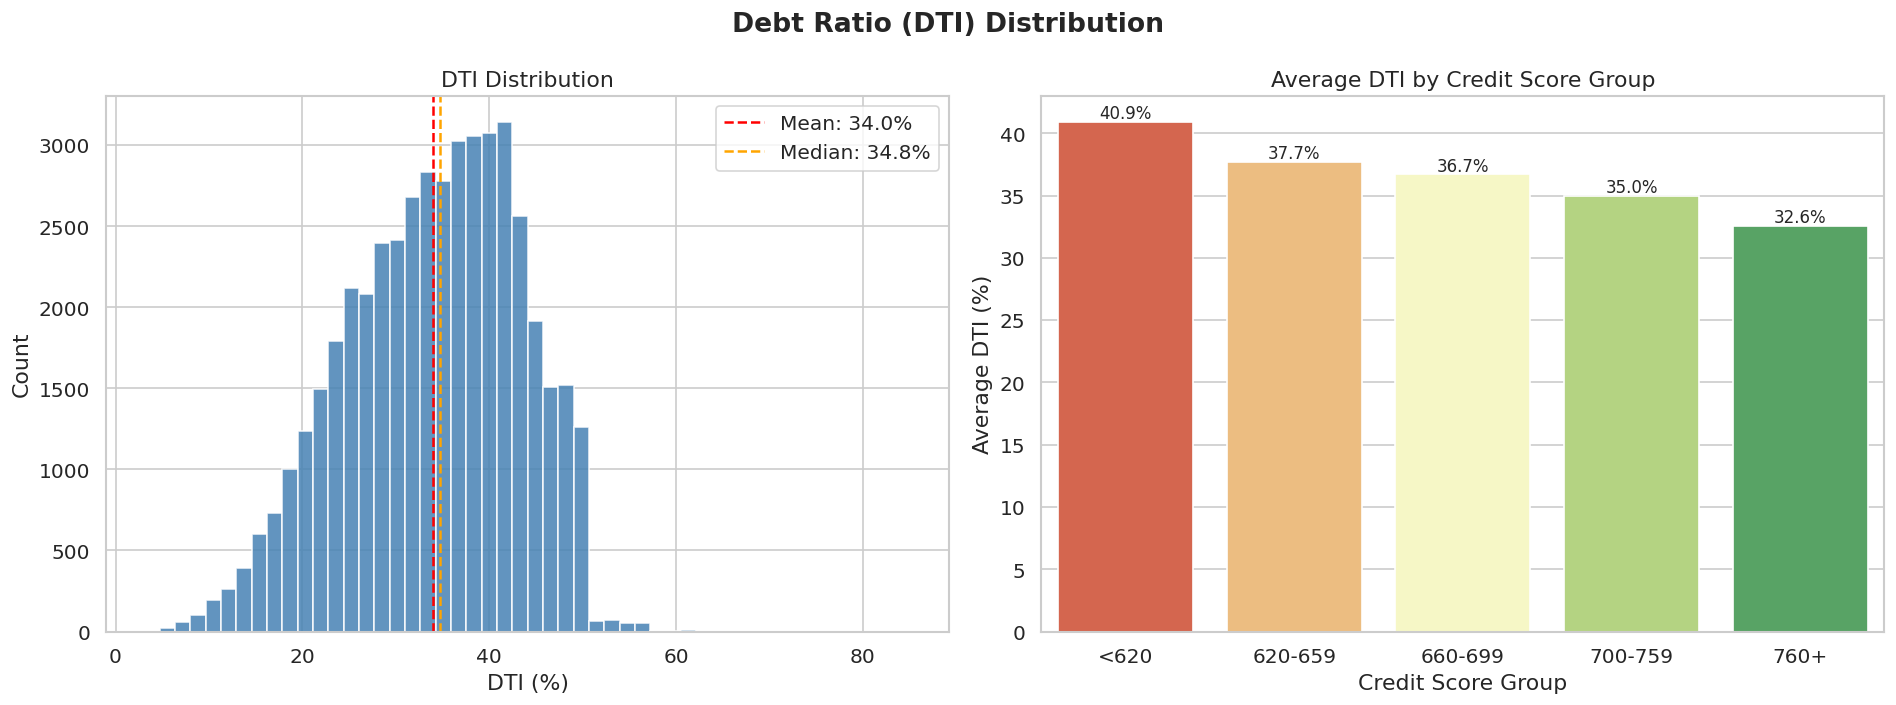

In [9]:
# ── Plot 6: Debt Ratio Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Debt Ratio (DTI) Distribution', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(df['TotalDebtExpenseRatioPercent'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['TotalDebtExpenseRatioPercent'].mean(),
                color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['TotalDebtExpenseRatioPercent'].mean():.1f}%")
axes[0].axvline(df['TotalDebtExpenseRatioPercent'].median(),
                color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['TotalDebtExpenseRatioPercent'].median():.1f}%")
axes[0].set_title('DTI Distribution')
axes[0].set_xlabel('DTI (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

# DTI by credit group
credit_order = ['<620', '620-659', '660-699', '700-759', '760+']
mean_dti_credit = df.groupby('credit_group')['TotalDebtExpenseRatioPercent'].mean().reindex(credit_order)
sns.barplot(x=mean_dti_credit.index, y=mean_dti_credit.values, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Average DTI by Credit Score Group')
axes[1].set_xlabel('Credit Score Group')
axes[1].set_ylabel('Average DTI (%)')
for i, v in enumerate(mean_dti_credit.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot6_dti_distribution.png', bbox_inches='tight')
plt.show()

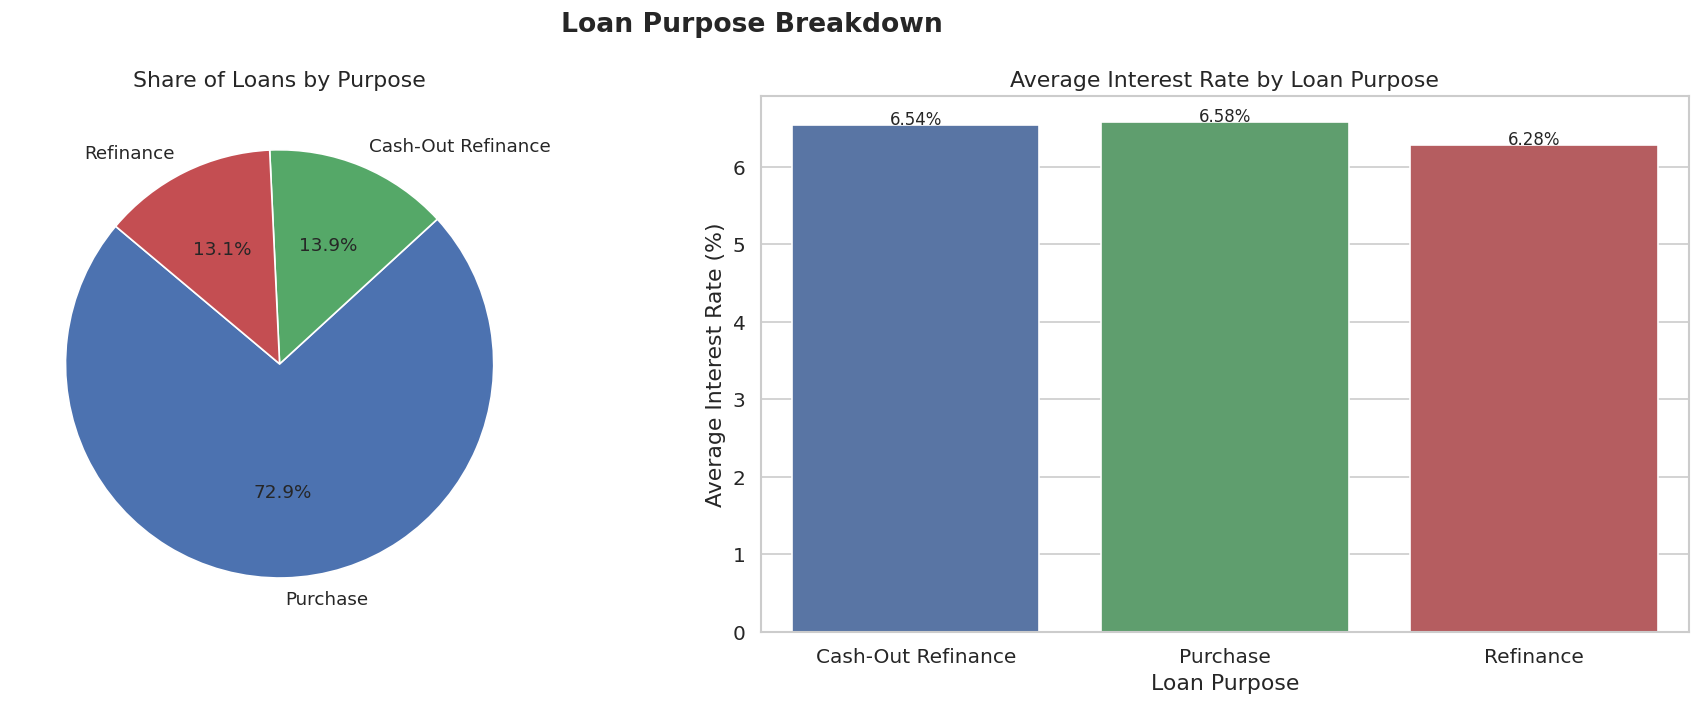

In [10]:
# ── Plot 7: Loan Purpose Breakdown ────────────────────────────────────────────
loan_purpose_map = {1: 'Purchase', 2: 'Refinance', 6: 'Cash-Out Refinance'}
df['LoanPurposeLabel'] = df['LoanPurposeType'].map(loan_purpose_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Loan Purpose Breakdown', fontsize=16, fontweight='bold')

# Count by loan purpose
purpose_counts = df['LoanPurposeLabel'].value_counts()
axes[0].pie(purpose_counts.values, labels=purpose_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0','#55A868','#C44E52'],
            startangle=140, textprops={'fontsize': 11})
axes[0].set_title('Share of Loans by Purpose')

# Avg interest rate by loan purpose
mean_rate = df.groupby('LoanPurposeLabel')['NoteRatePercent'].mean()
sns.barplot(x=mean_rate.index, y=mean_rate.values,
            palette=['#4C72B0','#55A868','#C44E52'], ax=axes[1])
axes[1].set_title('Average Interest Rate by Loan Purpose')
axes[1].set_xlabel('Loan Purpose')
axes[1].set_ylabel('Average Interest Rate (%)')
for i, v in enumerate(mean_rate.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot7_loan_purpose.png', bbox_inches='tight')
plt.show()